In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import nnls
import sys      



In [21]:
X_train_np = np.load('data/X_train_np.npy')
labels_list = np.load('data/labels_list.npy', allow_pickle=True)


In [22]:
# classification
labels_ints_list = []
# convert labels_list[String] -> labels_list[Int]
for label in labels_list:
    if label in ("generate_sparse_spectrum", "generate_narrow_absorption"):
        labels_ints_list.append(0)
    else:
        labels_ints_list.append(1)
np.save("data/labels_ints_list.npy", labels_ints_list)


In [23]:
# add classification network

class ClasificationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(25, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 2)

        # activation functions
        self.ReLU = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return x



In [24]:
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)
X_train_np_normalized = (X_train_np - mean) / std


In [25]:
# Generate PyTorch Dataset

class ClassificationDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype= torch.float32)
    self.y = torch.tensor(y, dtype= torch.long)

  # used to know when one epoch is done
  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


In [26]:
split = int(0.8 * len(X_train_np_normalized))
X_train_classify = X_train_np_normalized[:split]
X_val_classify  = X_train_np_normalized[split:]
y_train_classify  = labels_ints_list[:split]
y_val_classify  = labels_ints_list[split:]

train_dataset = ClassificationDataset(X_train_classify, y_train_classify)
val_dataset = ClassificationDataset(X_val_classify, y_val_classify)


In [27]:
train_classification_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_classification_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)

In [28]:

classificationModel = ClasificationNetwork()

classification_loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classificationModel.parameters(), lr=0.001)


In [29]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0.0

    classificationModel.train()

    for batch in train_classification_loader:
        x = batch[0]
        y = batch[1]

        predictions = classificationModel(x)
        loss = classification_loss_function(predictions, y)

        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        prediction = predictions.argmax(dim=1) 


    classificationModel.eval()
    with torch.no_grad():
        correct = 0
        total_val = 0
        val_loss = 0.0

        for i,  batch in enumerate(val_classification_loader):
            x = batch[0]
            y = batch[1]

            prediction = classificationModel(x)
            loss = classification_loss_function(prediction, y)

            result = (prediction.argmax(dim=1) == y )
            correct += result.sum().item()
            total_val += y.size(0)

            val_loss += loss.item()

    avg_loss = train_loss / len(train_classification_loader)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss}, Val Loss: {val_loss/len(val_classification_loader)}")
    print(f"Correct/Total: {correct/total_val}")










Epoch 1/10, Train Loss: 0.5339024054507414, Val Loss: 0.42233866453170776
Correct/Total: 0.8
Epoch 2/10, Train Loss: 0.2930917140717308, Val Loss: 0.20717152580618858
Correct/Total: 0.9266666666666666
Epoch 3/10, Train Loss: 0.1264028421137482, Val Loss: 0.09519882810612519
Correct/Total: 0.9716666666666667
Epoch 4/10, Train Loss: 0.07218907218581687, Val Loss: 0.08971783394614856
Correct/Total: 0.99
Epoch 5/10, Train Loss: 0.06003975272566701, Val Loss: 0.03897168021649122
Correct/Total: 0.9933333333333333
Epoch 6/10, Train Loss: 0.04440047042832399, Val Loss: 0.029673110616082948
Correct/Total: 0.995
Epoch 7/10, Train Loss: 0.03524006476315359, Val Loss: 0.03004349023103714
Correct/Total: 0.9966666666666667
Epoch 8/10, Train Loss: 0.031037959842554603, Val Loss: 0.028668556672831375
Correct/Total: 0.9966666666666667
Epoch 9/10, Train Loss: 0.02699402491756094, Val Loss: 0.022397778113372624
Correct/Total: 0.9966666666666667
Epoch 10/10, Train Loss: 0.02362823544535786, Val Loss: 0.01

In [30]:
classificationModel.eval()
with torch.no_grad():
    preds = classificationModel(torch.tensor(X_val_classify[:20], dtype=torch.float32)).argmax(dim=1)
    print(preds)
    print(y_val_classify[:20])

# 0 - 3
# generate_sparse_spectrum, generate_broad_emission,
        # generate_narrow_absorption, generate_broad_absorption

tensor([0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0])
[0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]


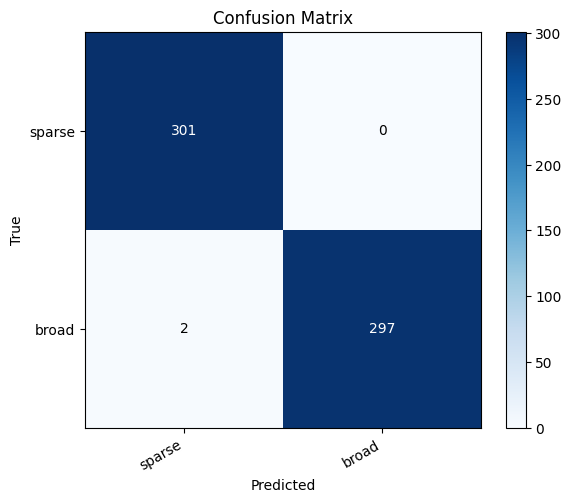

In [31]:
class_names = ['sparse', 'broad',]

classificationModel.eval()
with torch.no_grad():
    all_preds = classificationModel(torch.tensor(X_val_classify, dtype=torch.float32)).argmax(dim=1).numpy()
    all_labels = np.array(y_val_classify)

cm = np.zeros((2,2), dtype=int)
for true, pred in zip(all_labels, all_preds):
    cm[true][pred] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(2)); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticks(range(2)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()


In [32]:
torch.save(classificationModel.state_dict(), 'data/classification_model.pth')